# Random Forest Pipeline
Implements the Random Forest baseline as per `pipeline_design.txt` and prompt instructions.

In [1]:
import pandas as pd
import numpy as np
import json
import os
import joblib
import time
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import sys

print(f"Python: {sys.version}")
print(f"pandas: {pd.__version__}")
print(f"sklearn: {sklearn.__version__}")
print(f"joblib: {joblib.__version__}")

Python: 3.13.9 (tags/v3.13.9:8183fa5, Oct 14 2025, 14:09:13) [MSC v.1944 64 bit (AMD64)]
pandas: 2.3.3
sklearn: 1.8.0
joblib: 1.5.3


In [2]:
sys.path.append('.')
from config import SEED
print(f"Shared SEED: {SEED}")

Shared SEED: 42


In [3]:
out_dir = 'outputs/rf'
os.makedirs(out_dir, exist_ok=True)

In [4]:
# Load data and splits
print("Loading data...")
df = pd.read_parquet('cleaned_dataset.parquet')
feature_cols = [c for c in df.columns if c != 'label']

with open('split_indices.json', 'r') as f:
    splits = json.load(f)

assert splits['seed'] == SEED, "Seed mismatch between config.py and split_indices.json"

X_train = df.loc[splits['train_idx'], feature_cols].values
y_train = df.loc[splits['train_idx'], 'label'].values
X_val = df.loc[splits['val_idx'], feature_cols].values
y_val = df.loc[splits['val_idx'], 'label'].values
X_test = df.loc[splits['test_idx'], feature_cols].values
y_test = df.loc[splits['test_idx'], 'label'].values

print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Val shapes: X={X_val.shape}, y={y_val.shape}")
print(f"Test shapes: X={X_test.shape}, y={y_test.shape}")

Loading data...


Train shapes: X=(8118, 3078), y=(8118,)
Val shapes: X=(1740, 3078), y=(1740,)
Test shapes: X=(1740, 3078), y=(1740,)


In [5]:
# Preprocessing
# No preprocessing needed for RF (no scaling)
# Just save a null/no-op scaler to disk for uniformity
scaler = None
joblib.dump(scaler, os.path.join(out_dir, 'scaler.joblib'))
print("Null scaler saved.")

Null scaler saved.


In [6]:
# Train Random Forest
print("Training Random Forest...")
n_jobs = -1
rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=n_jobs
)
rf.fit(X_train, y_train)
print("Training complete.")

Training Random Forest...


Training complete.


In [7]:
# Evaluate metrics
print("Evaluating on test split...")
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
malware_f1 = f1_score(y_test, y_pred, pos_label=1)
cm = confusion_matrix(y_test, y_pred).tolist()
report = classification_report(y_test, y_pred, output_dict=True)

metrics = {
    'accuracy': acc,
    'macro_f1': macro_f1,
    'malware_f1': malware_f1,
    'confusion_matrix': cm,
    'classification_report': report
}

with open(os.path.join(out_dir, 'metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=4)

print(f"Accuracy: {acc:.4f}")
print(f"Macro-F1: {macro_f1:.4f}")
print(f"Malware F1: {malware_f1:.4f}")

Evaluating on test split...


Accuracy: 0.9638
Macro-F1: 0.9354
Malware F1: 0.9782


In [8]:
# Benchmark inference time
# Warm-up pass
_ = rf.predict(X_test)

print("Benchmarking inference time...")
single_sample = X_test[0:1]
single_times = []
for _ in range(100):
    start = time.perf_counter()
    rf.predict(single_sample)
    single_times.append(time.perf_counter() - start)

batch_times = []
for _ in range(100):
    start = time.perf_counter()
    rf.predict(X_test)
    batch_times.append(time.perf_counter() - start)

single_mean, single_std = np.mean(single_times), np.std(single_times)
batch_mean, batch_std = np.mean(batch_times), np.std(batch_times)

timing = {
    'n_jobs_used': n_jobs,
    'single_sample_latency_sec': {'mean': single_mean, 'std': single_std},
    'batch_throughput_sec': {'mean': batch_mean, 'std': batch_std},
    'batch_size': len(X_test)
}

with open(os.path.join(out_dir, 'timing.json'), 'w') as f:
    json.dump(timing, f, indent=4)

print(f"n_jobs used: {n_jobs}")
print(f"Single-sample latency: {single_mean:.5f}s ± {single_std:.5f}s")
print(f"Batch throughput: {batch_mean:.5f}s ± {batch_std:.5f}s")

Benchmarking inference time...


n_jobs used: -1
Single-sample latency: 0.05695s ± 0.00543s
Batch throughput: 0.09744s ± 0.01036s


In [9]:
# Measure model size
model_path = os.path.join(out_dir, 'model.joblib')
joblib.dump(rf, model_path)
file_size_bytes = os.path.getsize(model_path)
file_size_mb = file_size_bytes / (1024 * 1024)

total_nodes = sum(tree.tree_.node_count for tree in rf.estimators_)
avg_depth = np.mean([tree.tree_.max_depth for tree in rf.estimators_])

size_info = {
    'file_size_bytes': file_size_bytes,
    'file_size_mb': file_size_mb,
    'structural_complexity': {
        'num_trees': len(rf.estimators_),
        'average_tree_depth': avg_depth,
        'total_nodes': total_nodes
    }
}

with open(os.path.join(out_dir, 'size.json'), 'w') as f:
    json.dump(size_info, f, indent=4)

print(f"Model file size: {file_size_mb:.2f} MB")
print(f"Structural complexity: {len(rf.estimators_)} trees, avg depth {avg_depth:.2f}, {total_nodes} total nodes")

Model file size: 8.22 MB
Structural complexity: 300 trees, avg depth 21.34, 106228 total nodes


In [10]:
# Save artifacts
preds_df = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_pred,
    'y_pred_proba': y_pred_proba
})
preds_df.to_csv(os.path.join(out_dir, 'test_predictions.csv'), index=False)
print("All artifacts saved successfully.")

All artifacts saved successfully.


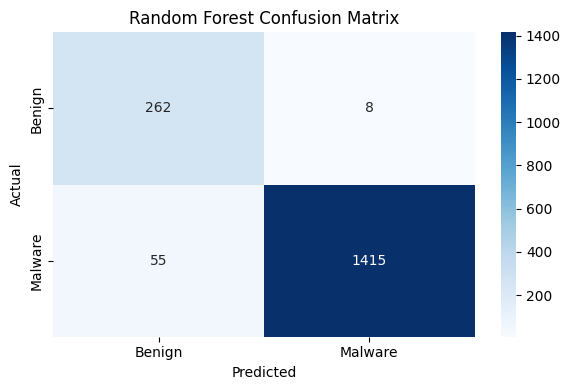

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malware'], yticklabels=['Benign', 'Malware'])
plt.title(f"{MODEL_NAME} Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

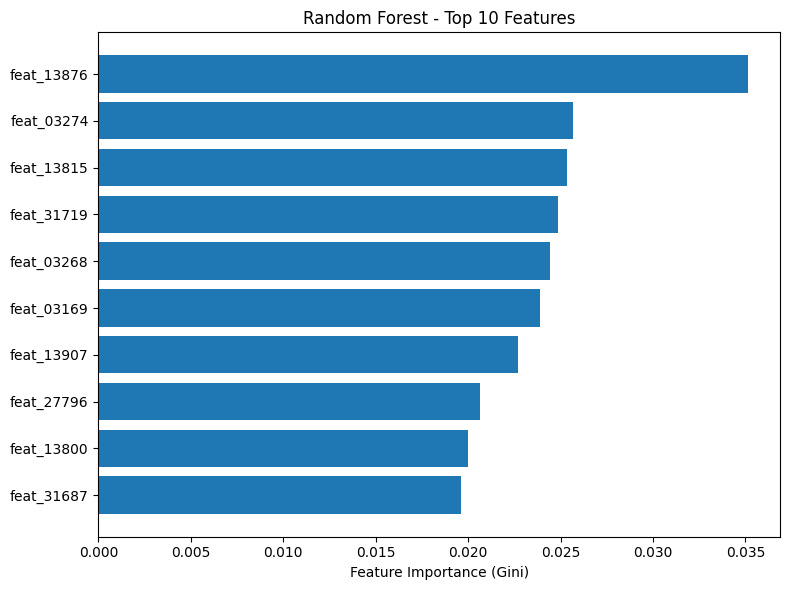

In [12]:
TOP_K_FEATURES = 10
import matplotlib.pyplot as plt
import pandas as pd
import os

importances = rf.feature_importances_
df_imp = pd.DataFrame({'feature': feature_cols, 'importance': importances})
df_imp = df_imp.sort_values('importance', ascending=False).head(TOP_K_FEATURES)

plt.figure(figsize=(8, 6))
plt.barh(df_imp['feature'][::-1], df_imp['importance'][::-1])
plt.xlabel('Feature Importance (Gini)')
plt.title('Random Forest - Top 10 Features')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()